In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [70]:
a = pd.read_csv(r"C:\Users\AROHI SINGH\Downloads\ABC_Retail_Sales_Dataset_1000_Rows.csv")

In [71]:
print(a.shape)
print(a.describe())

(1000, 11)
              Sales     Quantity     Discount       Profit
count   1000.000000  1000.000000  1000.000000  1000.000000
mean   25450.750840     5.489000     0.145310  3117.569130
std    14520.398949     2.882045     0.087353  2066.386896
min      106.720000     1.000000     0.000000     9.390000
25%    12772.607500     3.000000     0.070000  1345.540000
50%    25336.250000     5.000000     0.150000  2931.955000
75%    38362.560000     8.000000     0.220000  4465.585000
max    49973.450000    10.000000     0.300000  8678.900000


In [72]:
a['Order_Date'] = pd.to_datetime(a['Order_Date'])

In [73]:
a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Order_ID     1000 non-null   object        
 1   Order_Date   1000 non-null   datetime64[ns]
 2   Region       1000 non-null   object        
 3   State        1000 non-null   object        
 4   Customer_ID  1000 non-null   object        
 5   Category     1000 non-null   object        
 6   Product      1000 non-null   object        
 7   Sales        1000 non-null   float64       
 8   Quantity     1000 non-null   int64         
 9   Discount     1000 non-null   float64       
 10  Profit       1000 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(6)
memory usage: 86.1+ KB


In [74]:
print(a.head(5))

   Order_ID Order_Date Region        State Customer_ID         Category  \
0  ORD00001 2025-08-03   East  West Bengal    CUST5426  Office Supplies   
1  ORD00002 2025-10-21   East  West Bengal    CUST3433  Office Supplies   
2  ORD00003 2025-02-28   West  Maharashtra    CUST3558      Electronics   
3  ORD00004 2025-09-01  South    Telangana    CUST2528        Furniture   
4  ORD00005 2025-03-30   East  West Bengal    CUST9433  Office Supplies   

         Product     Sales  Quantity  Discount   Profit  
0  Printer Paper  39006.58         5      0.05  6241.05  
1       Notebook   2914.94         8      0.25   233.20  
2     Headphones  30621.49         9      0.09  4409.49  
3          Table  39280.28         3      0.11  5342.12  
4  Printer Paper   8609.15         7      0.00  1549.65  


In [75]:
print(a.isnull().sum())

Order_ID       0
Order_Date     0
Region         0
State          0
Customer_ID    0
Category       0
Product        0
Sales          0
Quantity       0
Discount       0
Profit         0
dtype: int64


In [76]:
print((a['Sales'] < 0).sum())
print((a['Quantity'] < 0).sum())
print((a['Discount'] < 0).sum())
print(a['Profit'].isnull().sum())

0
0
0
0


In [77]:
print(a[a.duplicated()])

Empty DataFrame
Columns: [Order_ID, Order_Date, Region, State, Customer_ID, Category, Product, Sales, Quantity, Discount, Profit]
Index: []


In [78]:
quality_report = pd.DataFrame({
    "Issue": [
        "Missing Values",
        "Duplicate Records",
        "Negative Sales",
        "Negative Quantity"
    ],
    "Count": [
        a.isnull().sum().sum(),
        a.duplicated().sum(),
        (a['Sales'] < 0).sum(),
        (a['Quantity'] < 0).sum()
    ]
})

quality_report

,Issue,Count
0,Missing Values,0
1,Duplicate Records,0
2,Negative Sales,0
3,Negative Quantity,0


In [79]:
a.columns

Index(['Order_ID', 'Order_Date', 'Region', 'State', 'Customer_ID', 'Category',
       'Product', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [80]:
total_sales = a['Sales'].sum()
total_profit = a['Profit'].sum()
total_quantity_sold = a['Quantity'].sum()
total_orders = a['Order_ID'].count()
average_discount = a['Discount'].mean()*100

print(f"Total Sales: ${total_sales:.2f}")
print(f"Total Profit: ${total_profit:.2f}")
print(f"Total Quantity Sold: {total_quantity_sold}")
print(f"Total Orders: {total_orders}")
print(f"Average Discount: {average_discount:.2f}%")  

Total Sales: $25450750.84
Total Profit: $3117569.13
Total Quantity Sold: 5489
Total Orders: 1000
Average Discount: 14.53%


In [81]:
#Summary statistics for Sales, Profit, Quantity, and Discount
metrics = ['mean', 'median', 'min', 'max']
columns = ['Sales', 'Profit', 'Quantity']

summary = a[columns].agg(metrics).round(2)

print("--- Dataset Analysis Summary ---")
print(summary)

--- Dataset Analysis Summary ---
           Sales   Profit  Quantity
mean    25450.75  3117.57      5.49
median  25336.25  2931.96      5.00
min       106.72     9.39      1.00
max     49973.45  8678.90     10.00


In [82]:
z = a.groupby('Region')[['Sales', 'Profit']].sum().round(2)
print(z)

             Sales     Profit
Region                       
East    7189592.98  855060.41
North   5982165.38  727358.58
South   6384142.64  785613.53
West    5894849.84  749536.61


C:\Users\AROHI SINGH\AppData\Local\Temp\ipykernel_25608\935312922.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=t5, x=sales_col, y=state_col, ax=axes[0], palette='Blues_r')
C:\Users\AROHI SINGH\AppData\Local\Temp\ipykernel_25608\935312922.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=b5, x=sales_col, y=state_col, ax=axes[1], palette='Reds_r')


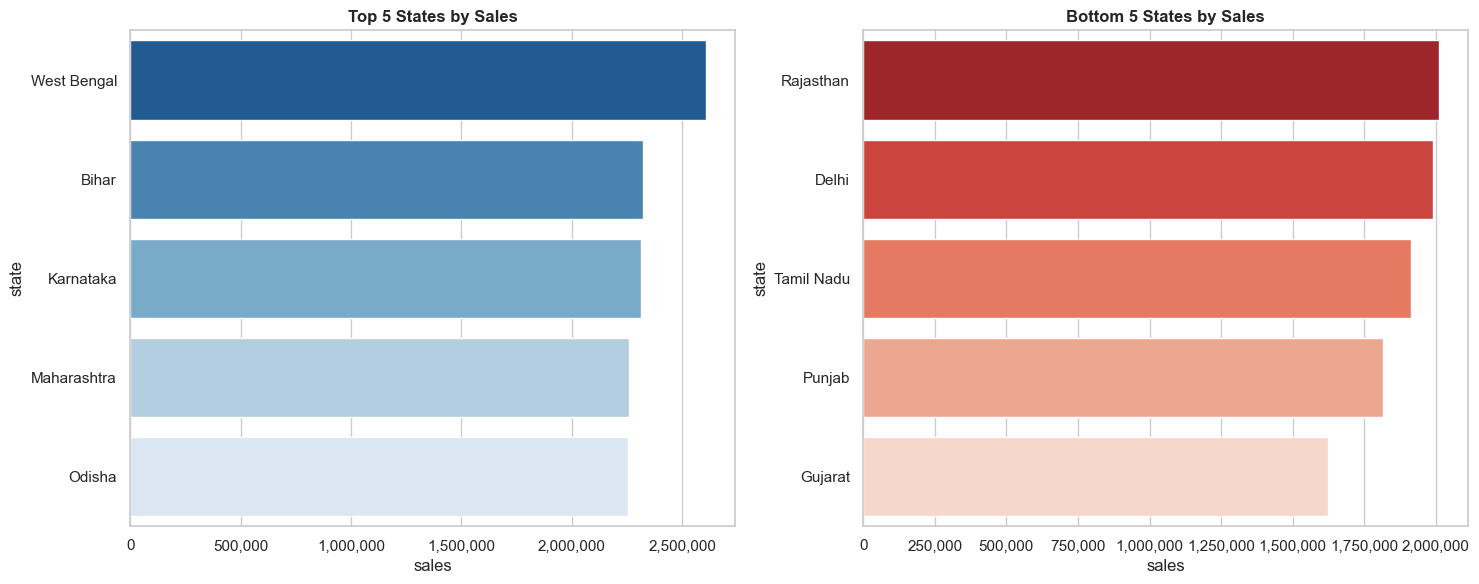

In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Force column names to be clean, lowercase strings
a.columns = a.columns.str.strip().str.lower()

# Find the exact column names dynamically
state_col = [c for c in a.columns if 'state' in c][0]
sales_col = [c for c in a.columns if 'sales' in c][0]

# Run the analysis using the dynamic names
st = a.groupby(state_col)[sales_col].sum().reset_index()
t5 = st.nlargest(5, sales_col)
b5 = st.nsmallest(5, sales_col).sort_values(sales_col, ascending=False)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(data=t5, x=sales_col, y=state_col, ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 5 States by Sales', fontweight='bold')
axes[0].xaxis.set_major_formatter('{x:,.0f}')

sns.barplot(data=b5, x=sales_col, y=state_col, ax=axes[1], palette='Reds_r')
axes[1].set_title('Bottom 5 States by Sales', fontweight='bold')
axes[1].xaxis.set_major_formatter('{x:,.0f}')

plt.tight_layout()
plt.savefig('state_sales.png', dpi=300)

C:\Users\AROHI SINGH\AppData\Local\Temp\ipykernel_25608\3638819205.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=p_sales, x=sales_col, y=prod_col, ax=axes[0], palette='Blues_r')
C:\Users\AROHI SINGH\AppData\Local\Temp\ipykernel_25608\3638819205.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=p_profit, x=profit_col, y=prod_col, ax=axes[1], palette='Greens_r')


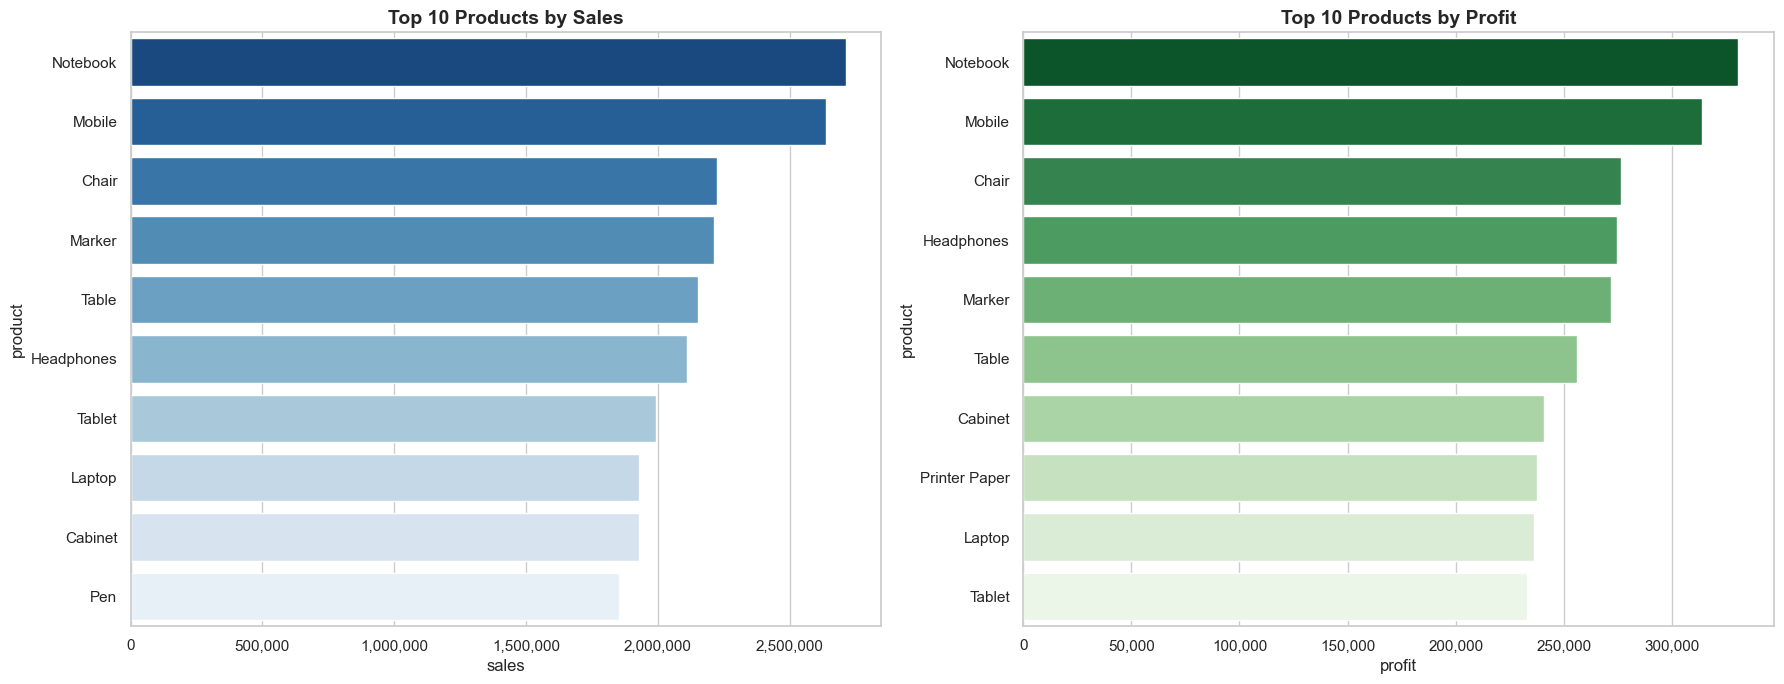

In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

a.columns = a.columns.str.strip().str.lower()
prod_col = [c for c in a.columns if 'product' in c][0]
sales_col = [c for c in a.columns if 'sales' in c][0]
profit_col = [c for c in a.columns if 'profit' in c][0]

p_sales = a.groupby(prod_col)[sales_col].sum().reset_index().nlargest(10, sales_col)
p_profit = a.groupby(prod_col)[profit_col].sum().reset_index().nlargest(10, profit_col)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(data=p_sales, x=sales_col, y=prod_col, ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 10 Products by Sales', fontweight='bold', fontsize=14)
axes[0].xaxis.set_major_formatter('{x:,.0f}')

sns.barplot(data=p_profit, x=profit_col, y=prod_col, ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 10 Products by Profit', fontweight='bold', fontsize=14)
axes[1].xaxis.set_major_formatter('{x:,.0f}')

plt.tight_layout()
plt.savefig('top_products.png', dpi=300)